In [1]:
# ============================================
# CELL 1: INSTALL LIBRARIES
# ============================================

!pip install -q langgraph langchain_core langchain_groq tavily-python python-dotenv langchain langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 17.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
# ============================================
# CELL 2: IMPORTS
# ============================================

from typing import Dict, TypedDict, Optional
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from tavily import TavilyClient
from dotenv import load_dotenv
import os
import json
from datetime import datetime

print("✓ All imports successful!")

✓ All imports successful!


In [3]:
# ============================================
# CELL 3: API KEYS SETUP
# ============================================

# Set your API keys here
os.environ["GROQ_API_KEY"] = "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"
os.environ["TAVILY_API_KEY"] = "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"

# Initialize clients
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
model_name = "llama-3.3-70b-versatile"

print("✓ API keys configured!")
print(f"✓ Using model: {model_name}")

✓ API keys configured!
✓ Using model: llama-3.3-70b-versatile


In [4]:
# ============================================
# CELL 4: STATE DEFINITION
# ============================================

class CompleteState(TypedDict):
    """State that flows through all 3 agents"""

    # User input
    query: str

    # Agent 1 outputs
    preferences: Optional[Dict]
    results: Optional[list]
    agent1_final: Optional[str]

    # Agent 2 outputs
    user_preferences: Optional[Dict]
    analysis: Optional[str]
    summary: Optional[str]

    # Agent 3 outputs
    final_recommendation: Optional[str]
    report_metadata: Optional[Dict]

print("✓ State structure defined!")

✓ State structure defined!


In [5]:
# ============================================
# CELL 5: AGENT 1 - PROPERTY SEARCH
# ============================================

def agent1_search(state: CompleteState) -> CompleteState:
    """Agent 1 Step 1: Search for properties using Tavily"""

    print("\n" + "="*70)
    print("🔍 AGENT 1: SEARCHING FOR PROPERTIES")
    print("="*70)

    query = state["query"][:800]

    # Refine query with LLM
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a real estate assistant. Format the user's query for an optimized property search in 400 words or less."),
        ("user", f"Query: {query}")
    ])

    chain = prompt | ChatGroq(model="llama-3.1-8b-instant", temperature=0, max_tokens=800)
    refined_query = chain.invoke({"query": query}).content

    if len(refined_query) > 800:
        refined_query = refined_query[:397].rsplit(" ", 1)[0] + "..."

    print(f"✓ Refined query: {refined_query[:100]}...")

    # Search using Tavily
    print("✓ Searching Zillow listings...")
    search_results = tavily_client.search(
        query=refined_query,
        include_domains=["zillow.com/homedetails"],
        max_results=3
    )

    print(f"✓ Found {len(search_results.get('results', []))} properties")

    state["preferences"] = {"refined_query": refined_query}
    state["results"] = search_results

    return state


def agent1_format(state: CompleteState) -> CompleteState:
    """Agent 1 Step 2: Format search results"""

    print("\n📝 Formatting search results...")

    results = state["results"].get("results", [])

    prompt = ChatPromptTemplate.from_messages([
        ("system", """Format the houses in a readable manner. Include if relevant:
        - Crime rate
        - Price
        - Property type
        - Commute to uptown
        - School district
        - Features
        Do not include preamble text."""),
        ("user", "Here are the search results: {results}")
    ])

    chain = prompt | ChatGroq(model="llama-3.1-8b-instant", temperature=0.3)
    response = chain.invoke({"results": results})

    state["agent1_final"] = response.content

    print("✓ Agent 1 complete!")

    return state

In [6]:
# ============================================
# CELL 6: AGENT 2 - ANALYSIS & RANKING
# ============================================

def agent2_analyze(state: CompleteState) -> CompleteState:
    """Agent 2 Step 1: Analyze and rate properties"""

    print("\n" + "="*70)
    print("📊 AGENT 2: ANALYZING PROPERTIES")
    print("="*70)

    agent1_output = state["agent1_final"]

    # Define user preferences (you can make this dynamic)
    user_prefs = {
        "budget_priority": "High - want best value under $450k",
        "safety_priority": "Very High - low crime is essential",
        "commute_priority": "Medium - prefer under 30 min",
        "schools_priority": "High - good schools important for resale",
        "other_notes": "Willing to pay more for safety and schools"
    }

    state["user_preferences"] = user_prefs

    # Analyze properties
    analysis_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a real estate analyst. Analyze each property and rate 1-10 based on user preferences.

Consider: price, crime rate, commute, schools, features.
Provide for each: strengths, weaknesses, key considerations, rating."""),
        ("user", """Properties from Agent 1:
{properties}

User Preferences:
{preferences}

Analyze each property with rating, strengths, and weaknesses.""")
    ])

    pref_text = "\n".join([f"- {k}: {v}" for k, v in user_prefs.items()])

    llm = ChatGroq(model=model_name, temperature=0.3)
    chain = analysis_prompt | llm

    print("✓ Analyzing properties...")
    response = chain.invoke({
        "properties": agent1_output,
        "preferences": pref_text
    })

    state["analysis"] = response.content

    print("✓ Analysis complete!")

    return state


def agent2_summarize(state: CompleteState) -> CompleteState:
    """Agent 2 Step 2: Create summary and rankings"""

    print("\n📋 Creating summary and rankings...")

    analysis = state["analysis"]

    summary_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a real estate advisor. Based on the analysis:
1. Rank properties from best to worst
2. Provide brief recommendation
3. Highlight top choice and why

Keep it clear and actionable."""),
        ("user", """Analysis:
{analysis}

Provide final summary with rankings and recommendation.""")
    ])

    llm = ChatGroq(model=model_name, temperature=0.3)
    chain = summary_prompt | llm

    response = chain.invoke({"analysis": analysis})

    state["summary"] = response.content

    print("✓ Agent 2 complete!")

    return state

In [7]:
# ============================================
# CELL 7: AGENT 3 - FINAL RECOMMENDATION
# ============================================

def agent3_generate_report(state: CompleteState) -> CompleteState:
    """Agent 3: Generate comprehensive final recommendation report"""

    print("\n" + "="*70)
    print("📝 AGENT 3: GENERATING FINAL REPORT")
    print("="*70)

    analysis = state["analysis"]
    summary = state["summary"]
    user_prefs = state["user_preferences"]

    # Generate comprehensive report
    report_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a professional real estate advisor. Create a clear, well-formatted final recommendation report.

Use:
- Clear section headers with ═══
- Bullet points with ✓ and ⚠
- Professional tone"""),
        ("user", """Create final recommendation report:

ANALYSIS:
{analysis}

SUMMARY:
{summary}

USER PRIORITIES:
{preferences}

---

Create report with these sections:

🏠 HOME BUYING RECOMMENDATION REPORT
═══════════════════════════════════
Date: {date}
Location: North Carolina
Budget: Under $450,000

EXECUTIVE SUMMARY
─────────────────
[3-4 sentences recommending #1 property and why]

TOP 3 PROPERTIES ANALYSIS
═════════════════════════

Property #1: [Name] - Rating: X/10 ⭐⭐⭐⭐
- Price: $XXX,XXX
- STRENGTHS ✓
  [list]
- WEAKNESSES ⚠
  [list]
- Best for: [buyer type]

[Repeat for Property #2 and #3]

🏆 FINAL RECOMMENDATION
═══════════════════════
RECOMMENDED: Property #1 - [Name]

[2-3 paragraphs explaining why based on user priorities]

CONFIDENCE LEVEL: High/Medium/Low

💰 FINANCIAL ESTIMATE (Property #1)
═══════════════════════════════════
- Purchase Price: $XXX,XXX
- Down Payment (20%): $XX,XXX
- Monthly Cost Est: $X,XXX

🎯 NEXT STEPS
═════════════
1. ✅ Schedule showing
2. ✅ Get pre-approved for mortgage
3. ✅ Conduct home inspection
4. ✅ Review HOA documents
5. ✅ Make offer

Be specific with all details from the analysis.""")
    ])

    prefs_text = "\n".join([f"• {k}: {v}" for k, v in user_prefs.items()])
    current_date = datetime.now().strftime("%B %d, %Y")

    llm = ChatGroq(model=model_name, temperature=0.2)
    chain = report_prompt | llm

    print("✓ Generating comprehensive report...")

    response = chain.invoke({
        "analysis": analysis,
        "summary": summary,
        "preferences": prefs_text,
        "date": current_date
    })

    report_text = response.content

    state["final_recommendation"] = report_text
    state["report_metadata"] = {
        "status": "success",
        "generated_date": current_date,
        "num_properties": 3
    }

    print("✓ Agent 3 complete!")

    return state

In [8]:
# ============================================
# CELL 8: BUILD COMPLETE WORKFLOW
# ============================================

# Create workflow
workflow = StateGraph(CompleteState)

# Add all agent nodes
workflow.add_node("agent1_search", agent1_search)
workflow.add_node("agent1_format", agent1_format)
workflow.add_node("agent2_analyze", agent2_analyze)
workflow.add_node("agent2_summarize", agent2_summarize)
workflow.add_node("agent3_report", agent3_generate_report)

# Connect the agents
workflow.set_entry_point("agent1_search")
workflow.add_edge("agent1_search", "agent1_format")
workflow.add_edge("agent1_format", "agent2_analyze")
workflow.add_edge("agent2_analyze", "agent2_summarize")
workflow.add_edge("agent2_summarize", "agent3_report")
workflow.add_edge("agent3_report", END)

# Compile
app = workflow.compile()

print("\n" + "="*70)
print("✅ COMPLETE WORKFLOW BUILT!")
print("="*70)
print("\nWorkflow: Agent 1 → Agent 2 → Agent 3")
print("  Agent 1: Search & Format Properties")
print("  Agent 2: Analyze & Rank")
print("  Agent 3: Generate Final Report")


✅ COMPLETE WORKFLOW BUILT!

Workflow: Agent 1 → Agent 2 → Agent 3
  Agent 1: Search & Format Properties
  Agent 2: Analyze & Rank
  Agent 3: Generate Final Report


In [9]:
# ============================================
# CELL 9: HELPER FUNCTIONS
# ============================================

def display_final_report(state: Dict):
    """Display the final report beautifully"""

    print("\n" + "="*70)
    print("📄 FINAL RECOMMENDATION REPORT")
    print("="*70 + "\n")

    print(state["final_recommendation"])

    print("\n" + "="*70)
    print("✅ REPORT GENERATION COMPLETE")
    print("="*70)


def save_report(state: Dict, filename="final_home_report.txt"):
    """Save report to file"""

    try:
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(state["final_recommendation"])
            f.write("\n\n" + "="*70 + "\n")
            f.write("METADATA\n")
            f.write("="*70 + "\n")

            metadata = state.get("report_metadata", {})
            f.write(f"Status: {metadata.get('status')}\n")
            f.write(f"Date: {metadata.get('generated_date')}\n")

        full_path = os.path.abspath(filename)
        print(f"\n💾 Report saved to: {full_path}")
        return True

    except Exception as e:
        print(f"❌ Error saving: {e}")
        return False

print("✓ Helper functions loaded!")

✓ Helper functions loaded!


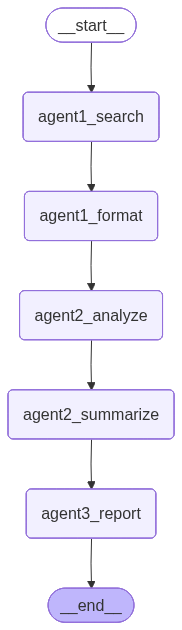

✓ Workflow diagram displayed above


In [11]:
# ============================================
# CELL 12: VISUALIZE WORKFLOW (Optional)
# ============================================

from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

try:
    display(
        Image(
            app.get_graph().draw_mermaid_png(
                draw_method=MermaidDrawMethod.API,
            )
        )
    )
    print("✓ Workflow diagram displayed above")
except:
    print("⚠️ Could not display diagram (requires internet connection)")

In [13]:
# ============================================
# CELL 13: TEST WITH DIFFERENT QUERY (Optional)
# ============================================

# Try a different search
test_query = "Find me a 1-bedroom house in Charlotte under $500k with good schools and safe neighborhood"

print(f"\n🧪 Testing with: {test_query}\n")

test_state = {
    "query": test_query,
    "preferences": None,
    "results": None,
    "agent1_final": None,
    "user_preferences": None,
    "analysis": None,
    "summary": None,
    "final_recommendation": None,
    "report_metadata": None
}

test_result = app.invoke(test_state)

print("\n" + "="*70)
print("TEST REPORT")
print("="*70)
print(test_result["final_recommendation"])


🧪 Testing with: Find me a 1-bedroom house in Charlotte under $500k with good schools and safe neighborhood


🔍 AGENT 1: SEARCHING FOR PROPERTIES
✓ Refined query: **Optimized Property Search Query:**

**Location:** Charlotte, NC
**Property Type:** Single-family h...
✓ Searching Zillow listings...
✓ Found 3 properties

📝 Formatting search results...
✓ Agent 1 complete!

📊 AGENT 2: ANALYZING PROPERTIES
✓ Analyzing properties...
✓ Analysis complete!

📋 Creating summary and rankings...
✓ Agent 2 complete!

📝 AGENT 3: GENERATING FINAL REPORT
✓ Generating comprehensive report...
✓ Agent 3 complete!

TEST REPORT
🏠 HOME BUYING RECOMMENDATION REPORT
═══════════════════════════════════
Date: October 16, 2025
Location: North Carolina
Budget: Under $450,000

EXECUTIVE SUMMARY
─────────────────
Based on the analysis of the top 3 properties, I highly recommend **House 3: 3049 Reid Ave, Charlotte, NC 28208**. Despite its higher price and lack of detailed information, its new build and spacious layout